Quick analysis on the generated evo datasets

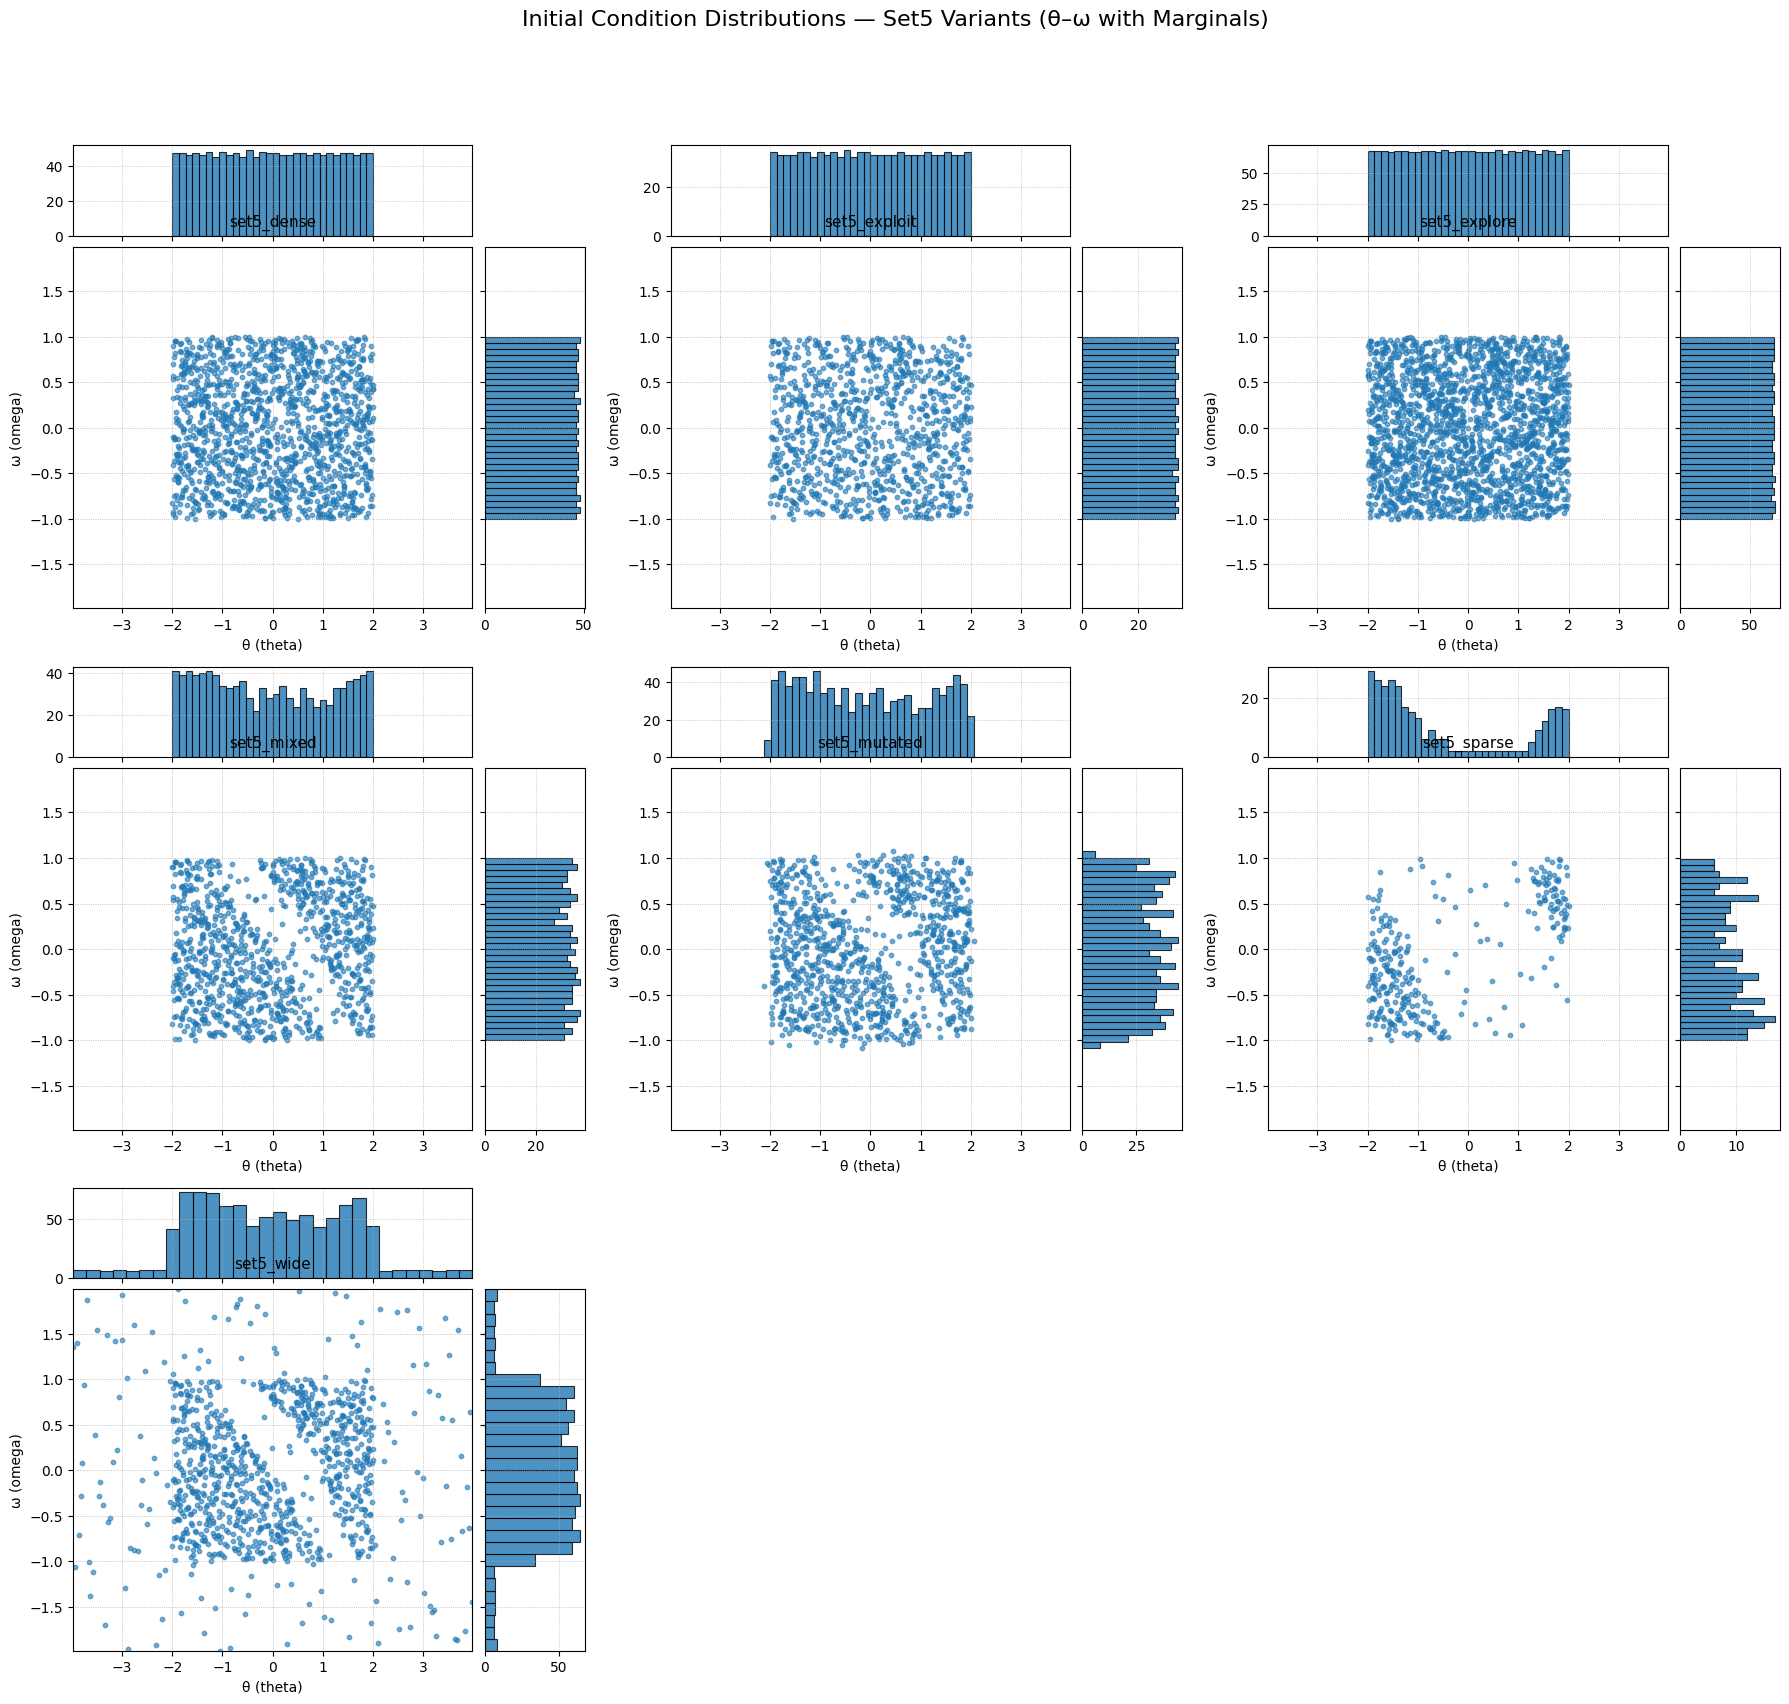

In [ ]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- CONFIG ---
data_dir = "data/SM_AVR_GOV"
datasets = [
    "dataset_set5_dense.pkl",
    "dataset_set5_exploit.pkl",
    "dataset_set5_explore.pkl",
    "dataset_set5_mixed.pkl",
    "dataset_set5_mutated.pkl",
    "dataset_set5_sparse.pkl",
    "dataset_set5_wide.pkl",
]

# Indices for variables: 0=theta, 1=omega
x_idx, y_idx = 0, 1

# --- Helper to load initial conditions ---
def load_dataset_initial_conditions(path):
    """Extract initial conditions (first state of each trajectory)."""
    with open(path, "rb") as f:
        dataset = pickle.load(f)
    ics = []
    for traj in dataset:
        if len(traj) > 1:
            y = np.array([arr[0] for arr in traj[1:]])  # first time step
            ics.append(y)
    return np.array(ics)

# --- Load datasets ---
all_ics = {}
for ds_name in datasets:
    ds_path = os.path.join(data_dir, ds_name)
    if os.path.exists(ds_path):
        name = ds_name.replace("dataset_", "").replace(".pkl", "")
        all_ics[name] = load_dataset_initial_conditions(ds_path)
    else:
        print(f"Missing dataset: {ds_name}")

# --- Global axis limits for consistency ---
x_all = np.concatenate([ics[:, x_idx] for ics in all_ics.values()])
y_all = np.concatenate([ics[:, y_idx] for ics in all_ics.values()])
xlim = (x_all.min(), x_all.max())
ylim = (y_all.min(), y_all.max())

# --- Figure setup ---
n_cols = 3
n_rows = int(np.ceil(len(all_ics) / n_cols))
fig = plt.figure(figsize=(6 * n_cols, 5.5 * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig)

for i, (name, ics) in enumerate(all_ics.items()):
    row, col = divmod(i, n_cols)
    inner_gs = gs[row, col].subgridspec(
        2, 2,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        wspace=0.05,
        hspace=0.05
    )

    # Create subplots for each dataset
    ax_histx = fig.add_subplot(inner_gs[0, 0])   # top θ marginal
    ax_histy = fig.add_subplot(inner_gs[1, 1])   # right ω marginal
    ax_scatter = fig.add_subplot(inner_gs[1, 0]) # main scatter

    # --- Scatter plot ---
    ax_scatter.scatter(ics[:, x_idx], ics[:, y_idx], s=10, alpha=0.6, color="tab:blue")
    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)
    ax_scatter.set_xlabel("θ (theta)")
    ax_scatter.set_ylabel("ω (omega)")
    ax_scatter.grid(True, linestyle=":", linewidth=0.6)
    ax_scatter.set_title(name, fontsize=11, pad=15)

    # --- X marginal (θ) — consistent style ---
    counts_x, bins_x = np.histogram(ics[:, x_idx], bins=30)
    bin_centers_x = 0.5 * (bins_x[:-1] + bins_x[1:])
    bar_width_x = bins_x[1] - bins_x[0]
    ax_histx.bar(
        bin_centers_x,
        counts_x,
        width=bar_width_x,
        color="tab:blue",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.8
    )
    ax_histx.set_xlim(xlim)
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histx.set_ylabel("")
    ax_histx.grid(True, linestyle=":", linewidth=0.5)

    # --- Y marginal (ω) — true 90° clockwise rotation, same style ---
    counts_y, bins_y = np.histogram(ics[:, y_idx], bins=30)
    bin_centers_y = 0.5 * (bins_y[:-1] + bins_y[1:])
    bar_width_y = bins_y[1] - bins_y[0]
    ax_histy.barh(
        bin_centers_y,
        counts_y,
        height=bar_width_y,
        color="tab:blue",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.8
    )
    ax_histy.set_ylim(ylim)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_xlabel("")
    ax_histy.grid(True, linestyle=":", linewidth=0.5)

# --- Global title and layout ---
fig.suptitle("Initial Condition Distributions — Set5 Variants (θ–ω with Marginals)",
             fontsize=16, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Each variant represents a distinct data regime to test both **interpolation** and **extrapolation** capabilities of the trained PINNs.

| Dataset | Description | Generation Strategy | Purpose |
|:--|:--|:--|:--|
| **set5_exploit** | Pure exploitation | Selects only high-error ICs from the previous LHS dataset (Set 4). Focuses sampling in regions where the model previously performed poorly. | Tests whether a model can specialize and overfit to challenging regions. |
| **set5_explore** | Pure exploration | Draws entirely new ICs uniformly/randomly across the full variable space. | Evaluates generalization under broad but unseen conditions. |
| **set5_mixed** | Balanced exploit/explore | Combines the top 80 % high-error ICs with 20 % new random ones. | Serves as a baseline, representing a realistic trade-off between focus and coverage. |
| **set5_wide** | Wider range | Expands the IC variable ranges beyond the nominal physical limits (out-of-distribution). | Probes extrapolation ability to unseen dynamic regimes. |
| **set5_mutated** | Perturbed exploitation | Adds Gaussian noise around the high-error ICs (small random mutations). | Tests local smoothness and robustness around known difficult regions. |
| **set5_sparse** | Low-density sampling | Subsamples the mixed dataset to reduce IC count. | Measures performance under limited data availability. |
| **set5_dense** | High-density sampling | Increases IC count relative to the mixed baseline. | Evaluates scaling with richer data coverage. |

### Key Notes
- All variants are generated via **Evo sampling**, which ranks ICs by their ODE residuals from Set 4 (LHS) and balances **exploration** (diversity) vs. **exploitation** (error-driven focus).
- Noise (when present) is added directly to the state variables at initialization, not to the time series.
- Each dataset contains trajectories solved with identical ODE parameters and simulation settings; only the initial condition distributions differ.
- These datasets form the foundation for the **cross-evaluation grid**, where one PINN trained on each dataset is tested on all others.

### Objective
By training and cross-evaluating models on these variants, we can:
1. Quantify **generalization vs. specialization trade-offs**.
2. Identify which dataset characteristics (range, density, focus) lead to the most **transferable PINN**.
3. Understand whether models trained on focused or diverse ICs can **extrapolate** to unseen regions of the system’s state space.